# Sentiment Analysis
## Comparative Study of Transformer-Based Models on Customer Review Data


###Install Dependencies


In [2]:
!pip install transformers datasets scikit-learn seaborn matplotlib torch torchvision
!pip install accelerate -U

### Imports


In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
from torch.utils.data import Dataset

### Setting Up Seeds for Reproducibility


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


###Load and Explore Dataset (IMDb)


In [5]:
# IMDb: binary sentiment — 0 = Negative, 1 = Positive
# 25,000 train / 25,000 test — balanced dataset
dataset = load_dataset("imdb")

print("Dataset structure:")
print(dataset)
print("\nSample review:")
print(dataset['train'][0]['text'][:300])
print(f"\nLabel: {'Positive' if dataset['train'][0]['label'] == 1 else 'Negative'}")

# Check class distribution
train_labels = dataset['train']['label']
label_counts = pd.Series(train_labels).value_counts()
print(f"\nClass distribution (Train):\n{label_counts}")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

Label: Negative

Class distribution (Train):
0    12500
1    12500
Name: count, dtype: int64


###Data Visualization — EDA


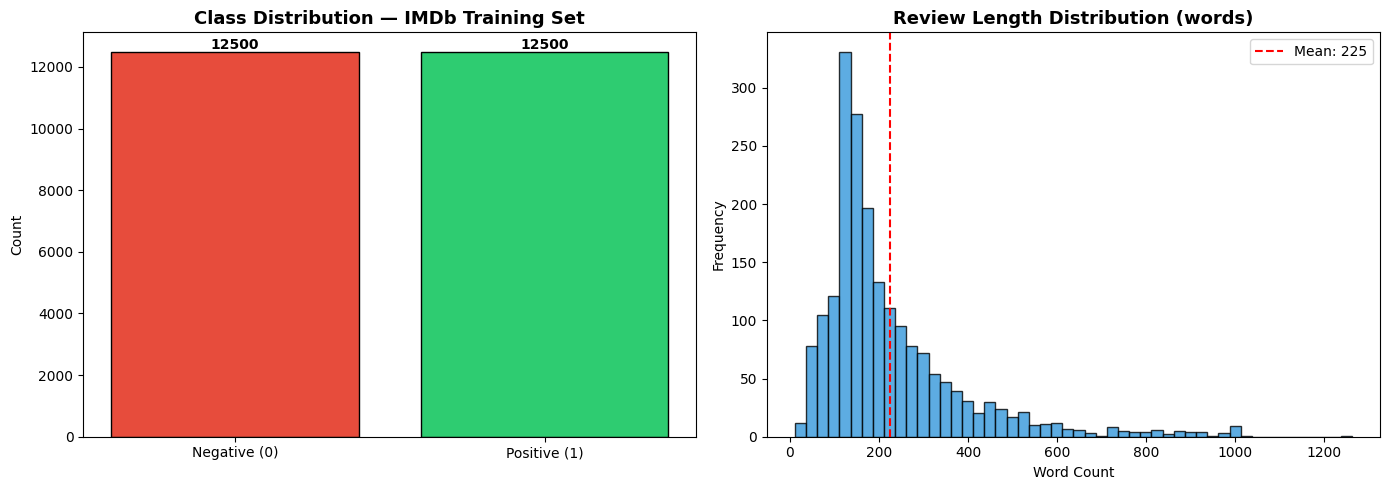

EDA plots saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 5a: Class distribution
axes[0].bar(['Negative (0)', 'Positive (1)'],
            [label_counts[0], label_counts[1]],
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution — IMDb Training Set', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([label_counts[0], label_counts[1]]):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# 5b: Review length distribution
train_texts = dataset['train']['text']
lengths = [len(t.split()) for t in train_texts[:2000]]  # sample 2000 for speed
axes[1].hist(lengths, bins=50, color='#3498db', edgecolor='black', alpha=0.8)
axes[1].set_title('Review Length Distribution (words)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {int(np.mean(lengths))}')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved.")

### Preprocessing & Subsampling


In [7]:
# Subsample for speed (2000 train / 500 val / 500 test per class)
# Remove for full training — will take several hours

SUBSAMPLE = True
TRAIN_SIZE = 2000   # per split (total)
VAL_SIZE   = 500
TEST_SIZE  = 500

def subsample_dataset(split, size):
    indices = random.sample(range(len(split)), size)
    return split.select(indices)

if SUBSAMPLE:
    train_data = subsample_dataset(dataset['train'], TRAIN_SIZE)
    # IMDb has no built-in val split — create from train
    full_train = dataset['train'].train_test_split(test_size=0.1, seed=42)
    train_data = subsample_dataset(full_train['train'], TRAIN_SIZE)
    val_data   = subsample_dataset(full_train['test'], VAL_SIZE)
    test_data  = subsample_dataset(dataset['test'], TEST_SIZE)
else:
    full_train = dataset['train'].train_test_split(test_size=0.1, seed=42)
    train_data = full_train['train']
    val_data   = full_train['test']
    test_data  = dataset['test']

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Train: 2000 | Val: 500 | Test: 500


### Custom Dataset Class


In [8]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

### Compute Metrics Function


In [9]:
def compute_metrics(pred):
    # ✅ Handle both Trainer + manual tuple
    if isinstance(pred, tuple):
        logits, labels = pred
    else:
        logits = pred.predictions
        labels = pred.label_ids

    preds = logits.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

### Training Function (reusable for all models)


In [10]:
def train_model(model_name, display_name, train_data, val_data, test_data,
                max_length=256, batch_size=16, epochs=3, lr=2e-5):
    print(f"\n{'='*60}")
    print(f"  Training: {display_name}")
    print(f"{'='*60}")

    # Tokenize
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # FIXED HERE ✅
    train_texts = [str(x) if x is not None else "" for x in train_data['text']]
    val_texts   = [str(x) if x is not None else "" for x in val_data['text']]
    test_texts  = [str(x) if x is not None else "" for x in test_data['text']]

    train_enc = tokenizer(train_texts, truncation=True,
                          padding=True, max_length=max_length)
    val_enc   = tokenizer(val_texts,   truncation=True,
                          padding=True, max_length=max_length)
    test_enc  = tokenizer(test_texts,  truncation=True,
                          padding=True, max_length=max_length)

    # Dataset objects
    train_ds = SentimentDataset(train_enc, train_data['label'])
    val_ds   = SentimentDataset(val_enc,   val_data['label'])
    test_ds  = SentimentDataset(test_enc,  test_data['label'])

    # Model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2)
    model.to(device)

    # Training Arguments
    output_dir = f"./results_{display_name.replace(' ', '_')}"
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        warmup_ratio=0.1,
        weight_decay=0.01,
        logging_dir=f"./logs_{display_name.replace(' ', '_')}",
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=42
    )

    # Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    # Train
    train_result = trainer.train()
    print(f"\nTraining complete. Time: {train_result.metrics['train_runtime']:.1f}s")

    # Evaluate on test set
    test_results = trainer.predict(test_ds)
    metrics = compute_metrics((test_results.predictions, test_results.label_ids))
    preds   = test_results.predictions.argmax(-1)
    labels  = test_results.label_ids

    print(f"\n--- {display_name} Test Results ---")
    print(f"  Accuracy : {metrics['accuracy']:.4f}")
    print(f"  F1 Score : {metrics['f1']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall   : {metrics['recall']:.4f}")

    return {
        'name':      display_name,
        'metrics':   metrics,
        'preds':     preds,
        'labels':    labels,
        'model':     model,
        'tokenizer': tokenizer
    }

### Train All Three Models


In [11]:
# NOTE: Each model takes ~5-15 min on T4 GPU with subsampling

models_to_compare = [
    ("bert-base-uncased",          "BERT-base"),
    ("distilbert-base-uncased",    "DistilBERT"),
    ("roberta-base",               "RoBERTa-base"),
]

all_results = []
for model_name, display_name in models_to_compare:
    result = train_model(
        model_name=model_name,
        display_name=display_name,
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        max_length=256,
        batch_size=16,
        epochs=3,
        lr=2e-5
    )
    all_results.append(result)


  Training: BERT-base


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete. Time: 244.9s



--- RoBERTa-base Test Results ---
  Accuracy : 0.9300
  F1 Score : 0.9299
  Precision: 0.9304
  Recall   : 0.9300


### Results Summary Table


In [12]:
results_df = pd.DataFrame([{
    'Model':     r['name'],
    'Accuracy':  r['metrics']['accuracy'],
    'F1 Score':  r['metrics']['f1'],
    'Precision': r['metrics']['precision'],
    'Recall':    r['metrics']['recall']
} for r in all_results])

results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
results_df.index += 1  # rank starting from 1

print("\n" + "="*65)
print("          COMPARATIVE RESULTS — TEST SET")
print("="*65)
print(results_df.to_string())
print("="*65)


          COMPARATIVE RESULTS — TEST SET
          Model  Accuracy  F1 Score  Precision  Recall
1  RoBERTa-base     0.930  0.929886   0.930380   0.930
2     BERT-base     0.890  0.889660   0.890945   0.890
3    DistilBERT     0.878  0.877745   0.878350   0.878


### Visualization — Performance Comparison Bar Chart


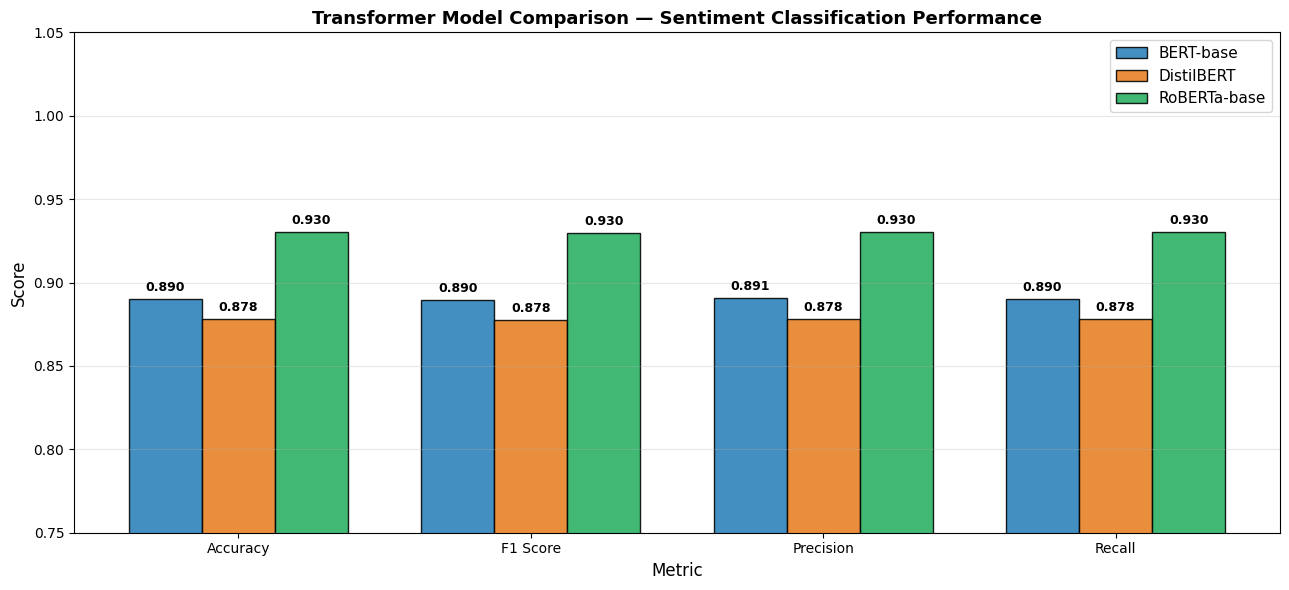

In [13]:
metrics_list = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
x = np.arange(len(metrics_list))
width = 0.25
colors = ['#2980b9', '#e67e22', '#27ae60']

fig, ax = plt.subplots(figsize=(13, 6))
for i, r in enumerate(all_results):
    values = [r['metrics']['accuracy'], r['metrics']['f1'],
              r['metrics']['precision'], r['metrics']['recall']]
    bars = ax.bar(x + i * width, values, width, label=r['name'],
                  color=colors[i], edgecolor='black', alpha=0.88)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Transformer Model Comparison — Sentiment Classification Performance',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_list)
ax.set_ylim(0.75, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Confusion Matrices for All Models


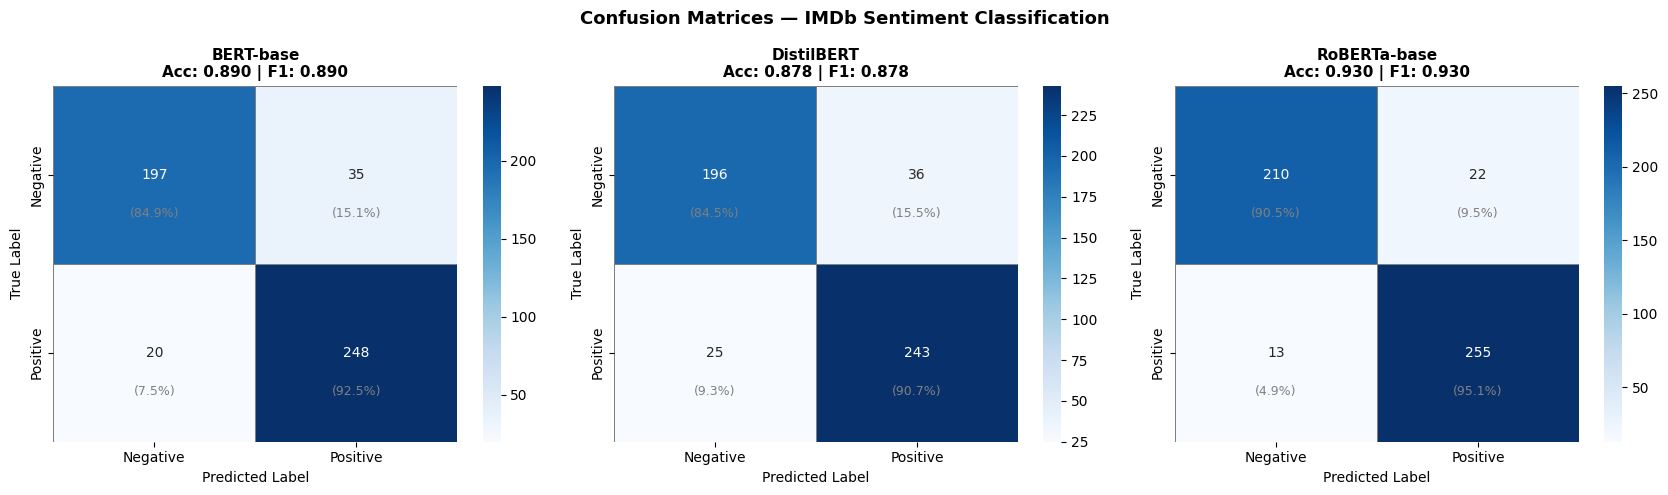

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
label_names = ['Negative', 'Positive']

for ax, r in zip(axes, all_results):
    cm = confusion_matrix(r['labels'], r['preds'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names,
                linewidths=0.5, linecolor='gray')

    # Overlay percentages
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f'({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=9, color='gray')

    ax.set_title(f'{r["name"]}\nAcc: {r["metrics"]["accuracy"]:.3f} | F1: {r["metrics"]["f1"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — IMDb Sentiment Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Per-Class Classification Report



──────────────────────────────────────────────────
Classification Report — BERT-base
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative     0.9078    0.8491    0.8775       232
    Positive     0.8763    0.9254    0.9002       268

    accuracy                         0.8900       500
   macro avg     0.8921    0.8873    0.8888       500
weighted avg     0.8909    0.8900    0.8897       500


──────────────────────────────────────────────────
Classification Report — DistilBERT
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative     0.8869    0.8448    0.8653       232
    Positive     0.8710    0.9067    0.8885       268

    accuracy                         0.8780       500
   macro avg     0.8789    0.8758    0.8769       500
weighted avg     0.8784    0.8780    0.8777       500


──────────────────────────────────────────────────
Classification Repo

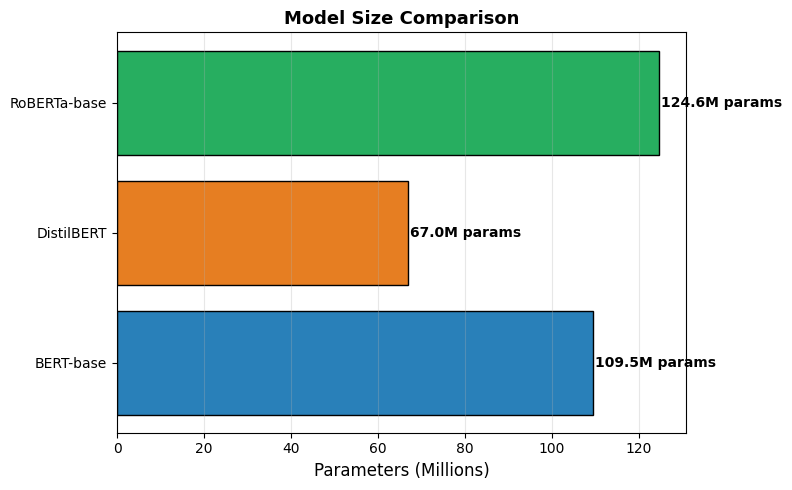

In [15]:
for r in all_results:
    print(f"\n{'─'*50}")
    print(f"Classification Report — {r['name']}")
    print('─'*50)
    print(classification_report(r['labels'], r['preds'],
                                target_names=label_names, digits=4))

# ─────────────────────────────────────────────
# CELL 15: Model Efficiency Comparison
# (Parameter counts & relative speed)
# ─────────────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters()) / 1e6  # in millions

param_data = {r['name']: count_params(r['model']) for r in all_results}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(list(param_data.keys()), list(param_data.values()),
               color=['#2980b9', '#e67e22', '#27ae60'], edgecolor='black')
for bar, val in zip(bars, param_data.values()):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2.,
            f'{val:.1f}M params', va='center', fontweight='bold')
ax.set_xlabel('Parameters (Millions)', fontsize=12)
ax.set_title('Model Size Comparison', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('model_size.png', dpi=150, bbox_inches='tight')
plt.show()

###Inference Demo — Predict on Custom Text


In [16]:
def predict_sentiment(text, model, tokenizer, label_map={0: 'Negative 😞', 1: 'Positive 😊'}):
    model.eval()
    inputs = tokenizer(text, return_tensors='pt',
                       truncation=True, max_length=256, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred  = probs.argmax()
    return label_map[pred], probs[0], probs[1]

# Use best model (first in sorted results)
best_result = max(all_results, key=lambda r: r['metrics']['f1'])
print(f"\nBest Model: {best_result['name']} (F1={best_result['metrics']['f1']:.4f})")

sample_texts = [
    "This movie was absolutely brilliant! The acting was superb and the plot was gripping.",
    "Terrible waste of time. The story made no sense and the acting was wooden.",
    "It was an okay film, nothing special but not terrible either.",
    "One of the best films I have ever watched. A masterpiece of modern cinema.",
    "Dreadful experience. Would not recommend to anyone.",
]

print(f"\n{'─'*65}")
print(f"{'Inference Demo':^65}")
print(f"{'─'*65}")
for text in sample_texts:
    label, neg_prob, pos_prob = predict_sentiment(
        text, best_result['model'], best_result['tokenizer'])
    print(f"\n> {text[:70]}...")
    print(f"  → {label} | Neg: {neg_prob:.3f} | Pos: {pos_prob:.3f}")


Best Model: RoBERTa-base (F1=0.9299)

─────────────────────────────────────────────────────────────────
                         Inference Demo                          
─────────────────────────────────────────────────────────────────

> This movie was absolutely brilliant! The acting was superb and the plo...
  → Positive 😊 | Neg: 0.007 | Pos: 0.993

> Terrible waste of time. The story made no sense and the acting was woo...
  → Negative 😞 | Neg: 0.997 | Pos: 0.003

> It was an okay film, nothing special but not terrible either....
  → Positive 😊 | Neg: 0.090 | Pos: 0.910

> One of the best films I have ever watched. A masterpiece of modern cin...
  → Positive 😊 | Neg: 0.008 | Pos: 0.992

> Dreadful experience. Would not recommend to anyone....
  → Negative 😞 | Neg: 0.889 | Pos: 0.111


### Save Final Summary CSV


In [17]:
results_df.to_csv('model_comparison_results.csv', index=False)
print("\nResults saved to model_comparison_results.csv")
print("\nAll output files generated:")
print("  ✓ eda_plots.png")
print("  ✓ model_comparison.png")
print("  ✓ confusion_matrices.png")
print("  ✓ model_size.png")
print("  ✓ model_comparison_results.csv")



Results saved to model_comparison_results.csv

All output files generated:
  ✓ eda_plots.png
  ✓ model_comparison.png
  ✓ confusion_matrices.png
  ✓ model_size.png
  ✓ model_comparison_results.csv
